In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor


In [2]:
df = pd.read_csv("../data/events.csv")
df.head()


,category,capacity,tags_count,interested_users_count,past_avg_attendance,attendance
0,Technology,86,4,59,84.0,78
1,Business,114,2,34,83.0,49
2,Sports,106,4,51,76.0,77
3,Science,241,2,26,100.0,52
4,Education,282,2,30,58.0,45


we will encode categorical column which is category to numerical

In [3]:
df = pd.get_dummies(df, columns=["category"])
df.head()

,capacity,tags_count,interested_users_count,past_avg_attendance,attendance,category_Arts,category_Business,category_Community,category_Education,category_Health,category_Medical,category_Science,category_Sports,category_Technology
0,86,4,59,84.0,78,False,False,False,False,False,False,False,False,True
1,114,2,34,83.0,49,False,True,False,False,False,False,False,False,False
2,106,4,51,76.0,77,False,False,False,False,False,False,False,True,False
3,241,2,26,100.0,52,False,False,False,False,False,False,True,False,False
4,282,2,30,58.0,45,False,False,False,True,False,False,False,False,False


------

In [13]:
df["interest_ratio"] = df["interested_users_count"] / df["capacity"]


splitting the data by 20/80,  20% test and 80% training

In [14]:
X = df.drop("attendance", axis=1)
y = df["attendance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


------

now we will train the model using LGBMRegressor()

In [15]:
model = LGBMRegressor()
model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 452
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 14
[LightGBM] [Info] Start training from score 36.997500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


now evaluation

In [16]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)


MAE: 2.1314365031677176


In [17]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

from sklearn.metrics import mean_absolute_error

print("Train MAE:", mean_absolute_error(y_train, train_preds))
print("Test MAE:", mean_absolute_error(y_test, test_preds))


Train MAE: 0.9695595351277642
Test MAE: 2.1314365031677176


In [18]:
errors = abs(y_test - model.predict(X_test))
print(errors.describe())


count    100.000000
mean       2.131437
std        1.642761
min        0.006660
25%        0.923485
50%        1.863113
75%        2.990217
max        9.876355
Name: attendance, dtype: float64


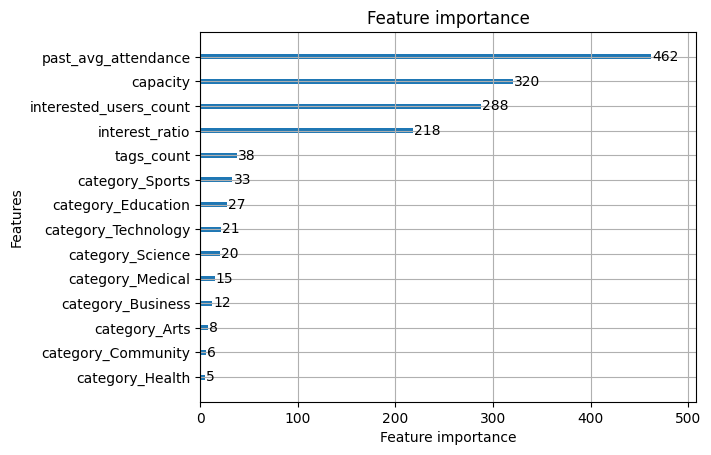

In [19]:
import matplotlib.pyplot as plt
from lightgbm import plot_importance

plot_importance(model)
plt.show()


In [27]:
import pandas as pd

def test_model(model, X_train_columns):

    test_cases = [
        {
            "name": "Low interest / low event",
            "capacity": 80,
            "interested_users_count": 10,
            "past_avg_attendance": 30,
            "tags_count": 1,
            "interest_ratio": 10/80,
            "category_Technology": 1,
            "category_Sports": 0,
            "category_Arts": 0,
            "category_Business": 0,
            "category_Science": 0,
            "category_Community": 0,
            "category_Health": 0,
            "category_Medical": 0,
            "category_Education": 0
        },
        {
            "name": "Medium interest / normal event",
            "capacity": 150,
            "interested_users_count": 60,
            "past_avg_attendance": 70,
            "tags_count": 3,
            "interest_ratio": 60/150,
            "category_Technology": 0,
            "category_Sports": 1,
            "category_Arts": 0,
            "category_Business": 0,
            "category_Science": 0,
            "category_Community": 0,
            "category_Health": 0,
            "category_Medical": 0,
            "category_Education": 0
        },
        {
            "name": "High interest / high demand",
            "capacity": 200,
            "interested_users_count": 120,
            "past_avg_attendance": 100,
            "tags_count": 4,
            "interest_ratio": 120/200,
            "category_Technology": 0,
            "category_Sports": 0,
            "category_Arts": 1,
            "category_Business": 0,
            "category_Science": 0,
            "category_Community": 0,
            "category_Health": 0,
            "category_Medical": 0,
            "category_Education": 0
        }
    ]

    for case in test_cases:
        name = case.pop("name")

        df_case = pd.DataFrame([case])


        df_case = df_case.reindex(columns=X_train_columns, fill_value=0)

        pred = model.predict(df_case)[0]

        print(f"{name}: {pred:.2f}")


In [29]:
import joblib

joblib.dump(model, "attendance_model.pkl")


['attendance_model.pkl']

In [30]:
joblib.dump(X_train.columns, "features.pkl")


['features.pkl']